In [1]:
import numpy as np
from numpy.random import seed, randn, rand
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import sys
print(sys.executable)

### Get MNIST data set

# Using scikit-learn (OpenML)
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)
print(X.shape)  # (70000, 784)
print(y.shape)  # (70000,)


# Using TensorFlow / Keras
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)  # (60000, 28, 28)
print(X_test.shape)   # (10000, 28, 28)


# Using PyTorch
import torch
import torchvision
from torchvision import datasets
mnist = datasets.MNIST(root="./data",train=True,download=True)
print(len(mnist))
print(torch.__version__)
print(torchvision.__version__)

from torchvision.datasets import MNIST


print("Setup complete")

c:\Users\iyke\anaconda3\python.exe
(70000, 784)
(70000,)
(60000, 28, 28)
(10000, 28, 28)


100%|██████████| 9.91M/9.91M [00:02<00:00, 3.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 276kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.04MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.05MB/s]

60000
2.12.1+cpu
0.27.1+cpu
Setup complete


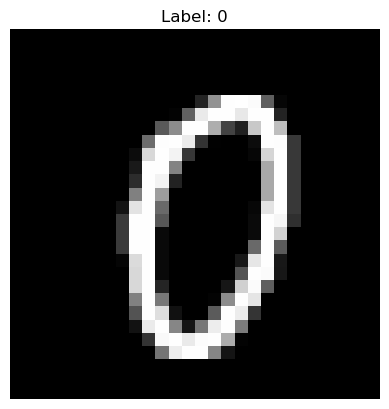

In [2]:
# Using scikit-learn (OpenML)
image = X[1000].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {y[1000]}")
plt.axis("off")
plt.show()

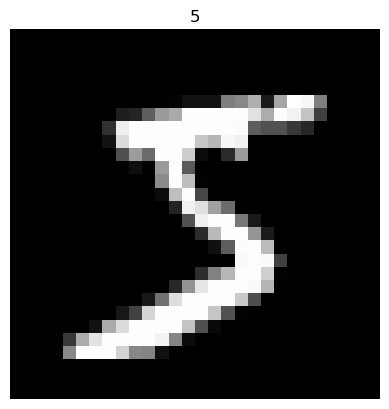

In [3]:
# Using TensorFlow / Keras
plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

0


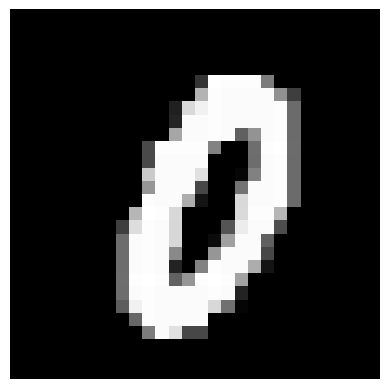

In [4]:
# Using PyTorch
image, label = mnist[34]
print(label)
#image.show() # Saves the image to a temporary file, launches the operating system's default image viewer and opens the image in that viewer
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

# <u>Digit classification</u>


**Goal:Classify handwritten digits ranging from 0 to 9 $\Rightarrow g=$ 10 class classification** 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/1.png" width="500"/>
</div>

Each data point/image has 28 $\times$ 28 pixels so 784 pixels in total. Each pixel value lies between 0 and 255 with 0 being a fully black pixel and 255 a fully white pixel.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/2.png" width="500"/>
</div>


In [5]:
# Load MNIST
mnist = MNIST(root="./data",train=True,download=True)

# Create 10x10 grid
rows = 10
cols = 10
img_size = 28

canvas = np.ones((rows * img_size, cols * img_size)) * 255

for i in range(rows):
    for j in range(cols):
        idx = i * cols + j
        image, label = mnist[idx]
        image = np.array(image)
        canvas[i*img_size:(i+1)*img_size,j*img_size:(j+1)*img_size] = image

# Plot with Plotly
fig = px.imshow(canvas,color_continuous_scale="gray",aspect="equal")
fig.update_layout(title="MNIST 10x10 Grid",coloraxis_colorbar_title="Pixel Value")

fig.show()

In [6]:
mnist = MNIST(root="./data",train=True,download=True)

digit_images = {d: [] for d in range(10)}

for image, label in mnist:
    if len(digit_images[label]) < 10:
        digit_images[label].append(np.array(image))

    if all(len(v) == 10 for v in digit_images.values()):
        break

canvas = np.ones((10*28, 10*28)) * 255

for row in range(10):
    for col in range(10):
        img = digit_images[col][row]
        canvas[row*28:(row+1)*28,col*28:(col+1)*28] = img

fig = px.imshow(canvas,color_continuous_scale="gray",aspect="equal")

fig.update_layout(title="MNIST Digits (Columns = 0,...,9)")

fig.show()

### Dataset

$$
\text{Data}=
\begin{bmatrix}
\text{Image 1} \\
\text{Image 2} \\

\vdots \\
\text{Image 70000} \\
\end{bmatrix}
=
\begin{bmatrix}
x^{(1)} \\
x^{(2)} \\

\vdots \\
x^{(70000)}\\
\end{bmatrix} \in \mathbb{R}^{70000 \times 784}, \quad
x^{(i)} \in \{0,1,2,\ldots,255\}^{784} \text{ for }i=1,\ldots,70000
$$

We will work with the transpose of that so

$$
\text{Data}=
\begin{bmatrix}
\text{Image 1} &
\text{Image 2} &

\ldots &
\text{Image 70000} \\
\end{bmatrix}
=
\begin{bmatrix}
x^{(1)} &
x^{(2)} &

\ldots &
x^{(70000)}\\
\end{bmatrix} \in \mathbb{R}^{784 \times 70000} \\[2 mm]
x^{(i)} \in \{0,1,2,\ldots,255\}^{784} \text{ for }i=1,\ldots,70000
$$

### Neural Network

$$
\hat{y}=  \text{Softmax}(W^{(2)}\text{ReLU}(W^{(1)}x + b^{(1)}) + b^{(2)})
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/3_.jpeg" width="600"/>
</div>

- $x$ of shape $(784 \times 1) \Rightarrow$ meaining we have one image at a times as input (for multiple inputs $x$ of shape $(784 \times m)$)
- $W^{(1)}$ of shape $(10 \times 784)$
- $b^{(1)}$ of shape $(10 \times 1)$
- $W^{(2)}$ of shape $(10 \times 10)$
- $b^{(2)}$ of shape $(10 \times 1)$
- $\text{ReLU}(x)=\max(0,x)$
- $\text{Softmax}(y)=\frac{\exp(y_i)}{\sum_{j=1}^n\exp(y_j)}$ for $y=(y_1,y_2,\ldots,y_n)$ and $i \in \{1,2,\ldots,n\}$



##### Forward pass
- $z^{(0)}=x$ of shape $(784 \times 1)$
- $a^{(1)}=W^{(1)}z^{(0)} + b^{(1)}$ of shape $(10 \times 1)$
- $z^{(1)}=\sigma(a^{(1)})=\text{ReLU}(a^{(1)})$ of shape $(10 \times 1)$
- $a^{(2)}=W^{(2)}z^{(1)} + b^{(2)}$ of shape $(10 \times 1)$
- $z^{(2)}=\text{Softmax}(a^{(2)})$ of shape $(10 \times 1)$
- $\hat{y}=z^{(2)}$ of shape $(10 \times 1)$
- Cross-entropy loss $L=-\sum_{i=0}^9 y_i \log(\hat{y_i})$

---

$$
\frac{\partial L}{\partial \hat{y}}=
$$

---

### Backward pass

$$
\begin{align*}
\frac{\partial L}{\partial b^{(2)}} &=  \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial b^{(2)}}= \\

\frac{\partial L}{\partial W^{(2)}} &=  \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial W^{(2)}}= \\

\frac{\partial L}{\partial b^{(1)}} &=  \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(2)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial b^{(1)}}= \\

\frac{\partial L}{\partial W^{(1)}} &=  \frac{\partial L}{\partial \hat{y}}\frac{\partial \hat{y}}{\partial a^{(2)}}\frac{\partial a^{(2)}}{\partial z^{(1)}}\frac{\partial z^{(2)}}{\partial a^{(1)}}\frac{\partial a^{(1)}}{\partial W^{(1)}}= \\
\end{align*}
$$


In [7]:
X, y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1342)

clf = MLPClassifier(hidden_layer_sizes=(100,),activation="relu",max_iter=20,random_state=1342)

clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.9746428571428571


c:\Users\iyke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.

